In [2]:
import os
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


In [3]:
# 1. Set paths
base = r"C:\Users\sebas\OneDrive\Documents\SSCI586 Programming and customization\Final Exam\Datasets"

haz_desbord_path = os.path.join(base, "amenaza_in_desbordamiento", "Amenaza_IN_desbordamiento_20211229.shp")
haz_jarillon_path = os.path.join(base, "amenaza_in_rompimiento_jarillo", "Amenaza_IN_rompimiento_jarillo_20211229.shp")
hydro_path       = os.path.join(base, "drenaje", "Drenaje.shp")
blocks_path      = os.path.join(base, "manzanas", "MANZANA.shp")
muni_path        = os.path.join(base, "munishp", "bogotapoly.shp")
   


In [4]:
# 2. Load data
haz_desb = gpd.read_file(haz_desbord_path)
haz_jar  = gpd.read_file(haz_jarillon_path)
hydro    = gpd.read_file(hydro_path)
blocks   = gpd.read_file(blocks_path)
muni     = gpd.read_file(muni_path)

print("CRS before:", haz_desb.crs, hydro.crs, blocks.crs, muni.crs)


CRS before: PROJCS["PCS_CarMAGBOG",GEOGCS["GCS_CarMAGBOG",DATUM["CGS_CarMAGBOG",SPHEROID["GRS80 Mod",6380687,298.257222101]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",4.680486111],PARAMETER["central_meridian",-74.14659167],PARAMETER["scale_factor",1],PARAMETER["false_easting",92334.879],PARAMETER["false_northing",109320.965],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]] EPSG:4686 EPSG:4326 EPSG:3857


In [5]:
# 3. Create a unified hazard layer with a hazard-type field ( I originally had two datasets: Jarillon and normal Desbordamineto)

haz_desb["HAZ_TYPE"] = "DESBORDAMIENTO"
haz_jar["HAZ_TYPE"]  = "ROMPIMIENTO_JARILLON"

haz_desb_simple = haz_desb[["HAZ_TYPE", "geometry"]].copy()
haz_jar_simple  = haz_jar[["HAZ_TYPE", "geometry"]].copy()

haz_all = gpd.GeoDataFrame(
    pd.concat([haz_desb_simple, haz_jar_simple], ignore_index=True),
    crs=haz_desb.crs
)
print("Hazard polygons (merged):", len(haz_all))


Hazard polygons (merged): 12


In [6]:
# 4. Reproject everything to EPSG:3116

target_crs = "EPSG:3116"

haz_all_3116 = haz_all.to_crs(target_crs)
hydro_3116   = hydro.to_crs(target_crs)
blocks_3116  = blocks.to_crs(target_crs)
muni_3116    = muni.to_crs(target_crs)

print("CRS after:", haz_all_3116.crs)

CRS after: EPSG:3116


In [7]:
# 5. Clip all layers to Bogotá municipal boundary
# if muni (original dataset with City polygon) has multiple polygons, dissolve to one
muni_union = muni_3116.dissolve()  # one multipart city polygon

haz_clip    = gpd.clip(haz_all_3116, muni_union)
hydro_clip  = gpd.clip(hydro_3116, muni_union)
blocks_clip = gpd.clip(blocks_3116, muni_union)

print("Clipped hazard polygons:", len(haz_clip))
print("Clipped blocks:", len(blocks_clip))

Clipped hazard polygons: 12
Clipped blocks: 43792


In [8]:
#Last step can take a while since the Parcel/block layer is pretty big 
# 6. Create a 100 m buffer around hydrology
# Buffer each line, then dissolve into one big polygon to simplify
hydro_buffer_geom = hydro_clip.buffer(100)   # 100 m
hydro_buffer      = gpd.GeoDataFrame(geometry=hydro_buffer_geom, crs=hydro_clip.crs)
hydro_buffer_diss = hydro_buffer.dissolve()
hydro_buffer_diss_clip = gpd.clip(hydro_buffer_diss, muni_union)

In [9]:
# 7. Intersect hydrology buffer with hazard polygons
haz_in_buffer = gpd.overlay(haz_clip, hydro_buffer_diss_clip, how="intersection")
print("Hazard polygons within 100 m of hydrology:", len(haz_in_buffer))

Hazard polygons within 100 m of hydrology: 12


In [10]:
# 8. Classify blocks into 4 categories:
#    Hazard & Buffer / Only Buffer / Only Hazard / None
# 8a. Flag blocks that intersect ANY hazard polygon
blocks_haz = gpd.sjoin(blocks_clip, haz_clip[["geometry"]],
                       how="left", predicate="intersects")
blocks_haz["IN_HAZARD"] = ~blocks_haz["index_right"].isna()
blocks_haz = blocks_haz.drop(columns=["index_right"])


In [11]:
# 8b. Flag blocks that intersect the 100 m buffer
blocks_buf = gpd.sjoin(blocks_haz, hydro_buffer_diss_clip[["geometry"]],
                       how="left", predicate="intersects")
blocks_buf["IN_BUFFER"] = ~blocks_buf["index_right"].isna()
blocks_buf = blocks_buf.drop(columns=["index_right"])


In [12]:
# 8c. Build 4-category risk label
def classify(row):
    if row["IN_HAZARD"] and row["IN_BUFFER"]:
        return "Hazard & Buffer"
    elif row["IN_BUFFER"] and not row["IN_HAZARD"]:
        return "Only Buffer"
    elif row["IN_HAZARD"] and not row["IN_BUFFER"]:
        return "Only Hazard"
    else:
        return "None"

blocks_buf["RISK_CAT"] = blocks_buf.apply(classify, axis=1)

blocks_riskcats = blocks_buf
print(blocks_riskcats["RISK_CAT"].value_counts())

RISK_CAT
None               31834
Only Buffer         8686
Only Hazard         2319
Hazard & Buffer     1484
Name: count, dtype: int64


In [13]:
# 9. Save outputs for ArcGIS Pro / final maps
out_folder = os.path.join(base, "outputs")
os.makedirs(out_folder, exist_ok=True)

haz_all_3116.to_file(os.path.join(out_folder, "Hazard_All_3116.shp"))
haz_clip.to_file(os.path.join(out_folder, "Hazard_Clip_Bogota.shp"))
hydro_buffer_diss_clip.to_file(os.path.join(out_folder, "Hydro_Buffer_100m.shp"))
haz_in_buffer.to_file(os.path.join(out_folder, "Hazard_within_100m_Drainage.shp"))
blocks_clip.to_file(os.path.join(out_folder, "Blocks_Clip_Bogota.shp"))
blocks_riskcats.to_file(os.path.join(out_folder, "Blocks_RiskCategories.shp"))


In [21]:
# NORTH ARROW FUNCTION
def add_north_arrow(ax, size=18, loc='upper left'):
    """
    Draws a north arrow pointing UP.
    loc: 'upper left', 'upper right', 'lower left', 'lower right'
    """
    offsets = {
        'upper left':  (0.05, 0.95),
        'upper right': (0.95, 0.95),
        'lower left':  (0.05, 0.15),
        'lower right': (0.95, 0.15)
    }
    x, y = offsets.get(loc, (0.05, 0.95))
    
    # N label
    ax.text(x, y, 'N', transform=ax.transAxes,
            fontsize=size, fontweight='bold',
            ha='center', va='center')

    # arrow pointing UP (tail below, head at y)
    ax.annotate(
        '', xy=(x, y), xytext=(x, y-0.1),
        xycoords='axes fraction', textcoords='axes fraction',
        arrowprops=dict(facecolor='black', width=4, headwidth=10)
    )


# SCALE BAR FUNCTION
def add_scalebar(ax, length=5000, location=(0.3, 0.05), linewidth=3):
    """
    length: length of scalebar in meters (EPSG:3116 uses meters)
    location: (x, y) in axes fraction coordinates
    """
    x_frac, y_frac = location
    disp_x, disp_y = ax.transAxes.transform((x_frac, y_frac))
    data_x, data_y = ax.transData.inverted().transform((disp_x, disp_y))

    # draw bar
    ax.plot([data_x, data_x + length], [data_y, data_y],
            color='black', linewidth=linewidth)

    # label – use km if >= 1000 m
    if length >= 1000:
        value = length / 1000
        unit = "km"
    else:
        value = length
        unit = "m"

    ax.text(data_x + length/2,
            data_y - (length * 0.0003),
            f"{value:g} {unit}",
            ha='center', va='top', fontsize=10)

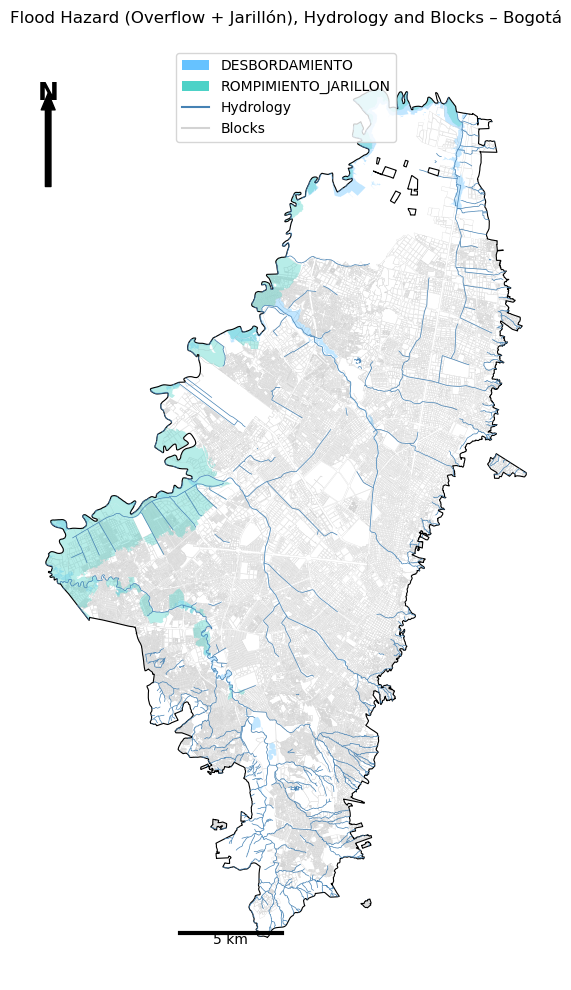

In [22]:
# 10. Map 1 – Hazard & Hydrology context
fig, ax = plt.subplots(figsize=(10, 10))

# base layers
muni_union.boundary.plot(ax=ax, color="black", linewidth=0.8)
blocks_clip.plot(ax=ax, edgecolor="lightgrey", facecolor="none", linewidth=0.2)

# hazards
haz_colors = {"DESBORDAMIENTO": "#66c2ff", "ROMPIMIENTO_JARILLON": "#4dd2c7"}
for haz_type, color in haz_colors.items():
    haz_clip[haz_clip["HAZ_TYPE"] == haz_type].plot(
        ax=ax, color=color, alpha=0.4, linewidth=0
    )

# hydrology
hydro_clip.plot(ax=ax, linewidth=0.5, color="steelblue")

# legends
patches = [Patch(facecolor=c, edgecolor="none", label=k) for k, c in haz_colors.items()]
line_hydro = Line2D([0], [0], color="steelblue", linewidth=1.5, label="Hydrology")
line_blocks = Line2D([0], [0], color="lightgrey", linewidth=1.5, label="Blocks")
ax.legend(handles=patches + [line_hydro, line_blocks],
          loc="upper center", frameon=True)

# NORTH ARROW + SCALE BAR
add_north_arrow(ax, size=18, loc='upper left')
add_scalebar(ax, length=5000)   # 5 km bar, much more visible

ax.set_title("Flood Hazard (Overflow + Jarillón), Hydrology and Blocks – Bogotá")
ax.set_axis_off()
plt.tight_layout()
plt.show()

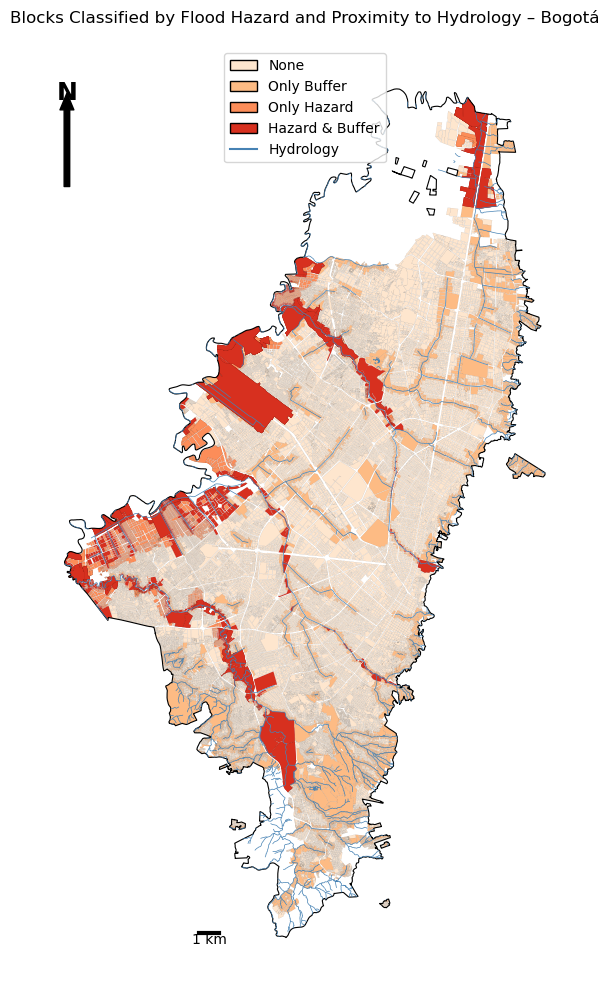

In [24]:
fig, ax = plt.subplots(figsize=(10, 10))

# base boundary
muni_union.boundary.plot(ax=ax, color="black", linewidth=0.8)

# block categories in orange scale
risk_colors = {
    "None":            "#fee6ce",
    "Only Buffer":     "#fdbb84",
    "Only Hazard":     "#fc8d59",
    "Hazard & Buffer": "#d7301f"
}

for cat, color in risk_colors.items():
    blocks_riskcats[blocks_riskcats["RISK_CAT"] == cat].plot(
        ax=ax, facecolor=color, edgecolor="black", linewidth=0.03, label=cat
    )

# hydrology
hydro_clip.plot(ax=ax, linewidth=0.5, color="steelblue")

# legend
patches_risk = [Patch(facecolor=c, edgecolor="black", label=l)
                for l, c in risk_colors.items()]
line_hydro2 = Line2D([0], [0], color="steelblue", linewidth=1.5, label="Hydrology")

ax.legend(handles=patches_risk + [line_hydro2],
          loc="upper center", frameon=True)

# NORTH ARROW + SCALE BAR
add_north_arrow(ax, size=18)
add_scalebar(ax, length=1000)

ax.set_title("Blocks Classified by Flood Hazard and Proximity to Hydrology – Bogotá")
ax.set_axis_off()
plt.tight_layout()
plt.show()